# Distribution Demand Forecasting: Leakage-Safe Feature Engineering

*Source project:* `demand-forecast/` (private distribution-forecasting repo; the current
2026 production demand-forecasting pipeline for a distribution business).

This notebook recreates the **leakage-prevention logic** from the production feature
engineers -- `src/features/lag.py` (`LagFeatureEngineer`) and
`src/features/rolling.py` (`RollingFeatureEngineer`) -- and the SBC demand-pattern
classification from `docs/technical_summary.md`. It runs on a **synthetic** weekly
demand panel generated here; no real client data (stock IDs, warehouse codes,
quantities, or the raw ERP demand export) is used or shown.

The single most important idea: a feature at week *t* must only use information
available *before* week *t*. Lags use `.shift(lag)`; rolling stats use
`.shift(1).rolling(window)` so the current week is never inside its own feature.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(7)
plt.rcParams['figure.dpi'] = 80

## 1. Synthetic weekly demand panel

Distribution demand is often **intermittent** (an item might sell some weeks and
not others) with occasional large orders. We build a few synthetic Stock/Warehouse
series with that flavor. IDs are made up (`SKU_A`, warehouse `W1`) -- nothing from the
real client.

In [2]:
def make_series(n_weeks, adi, base, cv, start='2022-01-03'):
    '''Weekly demand: sells with prob 1/adi; positive qty is noisy around `base`.'''
    weeks = pd.date_range(start=start, periods=n_weeks, freq='W-MON')
    sells = RNG.random(n_weeks) < (1.0 / adi)
    qty = np.where(sells,
                   np.maximum(0, RNG.normal(base, base * cv, n_weeks)).round(),
                   0.0)
    return weeks, qty

specs = [
    ('SKU_A', 'W1', 1.05, 40, 0.25),   # smooth-ish: sells most weeks, steady qty
    ('SKU_A', 'W2', 2.20, 30, 0.90),   # lumpy: sells rarely, variable qty
    ('SKU_B', 'W1', 1.10, 55, 0.70),   # erratic: sells often, variable qty
]
frames = []
for stock, wh, adi, base, cv in specs:
    weeks, qty = make_series(140, adi, base, cv)
    frames.append(pd.DataFrame({'Stock': stock, 'Warehouse': wh,
                                'Date': weeks, 'Year': weeks.isocalendar().year.values,
                                'Week': weeks.isocalendar().week.values,
                                'Demand': qty}))
df = pd.concat(frames, ignore_index=True)
print(df.shape)
df.head()

(420, 6)


,Stock,Warehouse,Date,Year,Week,Demand
0,SKU_A,W1,2022-01-03,2022,1,30.0
1,SKU_A,W1,2022-01-10,2022,2,51.0
2,SKU_A,W1,2022-01-17,2022,3,35.0
3,SKU_A,W1,2022-01-24,2022,4,39.0
4,SKU_A,W1,2022-01-31,2022,5,32.0


## 2. Lag features (leakage-safe)

Recreates `LagFeatureEngineer`. Key properties from the production docstring:

- weekly lags `[1, 2, 4, 13, 52]` (recent history, monthly, quarterly, annual);
- an optional `log1p` transform *before* lagging (demand is skewed);
- lags are computed **per Stock/Warehouse group** so one item never borrows another's
  history;
- `.shift(lag)` only looks backward, so no future information leaks in;
- **dynamic selection**: drop any lag longer than 80% of a series' length to avoid
  all-null columns on short series.

In [3]:
WEEKLY_LAGS = [1, 2, 4, 13, 52]


def get_valid_lags(lags, series_length, threshold=0.8):
    '''Dynamic lag selection (lag.py::get_valid_lags).'''
    max_lag = int(series_length * threshold)
    valid = [l for l in lags if l <= max_lag]
    if not valid and series_length > 1:
        valid = [1]
    return valid


def add_lag_features(df, lags=WEEKLY_LAGS, target='Demand', log_transform=True):
    '''Leakage-safe lag features (adapted from lag.py::transform).'''
    out = df.sort_values(['Stock', 'Warehouse', 'Year', 'Week']).copy()
    prefix = 'feat_log_lag' if log_transform else 'feat_lag'
    base = np.log1p(np.maximum(out[target].values, 0)) if log_transform else out[target].values
    out['_t'] = base
    for lag in lags:
        out[f'{prefix}_{lag}'] = np.nan
    for (s, w), g in out.groupby(['Stock', 'Warehouse']):
        for lag in get_valid_lags(lags, len(g)):
            out.loc[g.index, f'{prefix}_{lag}'] = g['_t'].shift(lag)
    return out.drop(columns='_t')

lagged = add_lag_features(df)
cols = ['Stock', 'Warehouse', 'Week', 'Demand', 'feat_log_lag_1', 'feat_log_lag_2', 'feat_log_lag_4']
lagged[lagged['Stock'] == 'SKU_A'][cols].head(8)

,Stock,Warehouse,Week,Demand,feat_log_lag_1,feat_log_lag_2,feat_log_lag_4
0,SKU_A,W1,1,30.0,NaN,NaN,NaN
1,SKU_A,W1,2,51.0,3.433987,NaN,NaN
2,SKU_A,W1,3,35.0,3.951244,3.433987,NaN
3,SKU_A,W1,4,39.0,3.583519,3.951244,NaN
4,SKU_A,W1,5,32.0,3.688879,3.583519,3.433987
5,SKU_A,W1,6,34.0,3.496508,3.688879,3.951244
6,SKU_A,W1,7,27.0,3.555348,3.496508,3.583519
7,SKU_A,W1,8,53.0,3.332205,3.555348,3.688879


### Proof there's no leakage

For any row, `feat_log_lag_1` must equal `log1p(Demand)` from the *previous* week of
the *same* group -- never the current week. This mirrors
`tests/test_data_leakage.py` in the production repo.

In [4]:
g = lagged[(lagged['Stock'] == 'SKU_A') & (lagged['Warehouse'] == 'W1')].reset_index(drop=True)
expected = np.log1p(np.maximum(g['Demand'], 0)).shift(1)
check = g['feat_log_lag_1']
# compare where both defined
mask = check.notna() & expected.notna()
assert np.allclose(check[mask], expected[mask]), "lag_1 leaked!"
print("PASS: feat_log_lag_1[t] == log1p(Demand)[t-1] for all rows (no current-week info)")

PASS: feat_log_lag_1[t] == log1p(Demand)[t-1] for all rows (no current-week info)


## 3. Rolling features (leakage-safe)

Recreates `RollingFeatureEngineer`. The critical line is `.shift(1)` **before**
`.rolling()`, so `rolling_mean_4` at week *t* is the mean of weeks *t-1 .. t-4* and
**excludes** week *t* itself. Windows are weekly `[4, 13, 26, 52]`; same per-group,
dynamic-selection rules as lags.

In [5]:
WEEKLY_WINDOWS = [4, 13, 26, 52]


def _rolling_stat(series, window, stat, min_periods=2):
    '''shift(1) BEFORE rolling -> current period excluded (rolling.py).'''
    r = series.shift(1).rolling(window=window, min_periods=min_periods)
    return getattr(r, stat)()


def add_rolling_features(df, windows=WEEKLY_WINDOWS, stats=('mean', 'std'),
                         target='Demand', threshold=0.8):
    out = df.sort_values(['Stock', 'Warehouse', 'Year', 'Week']).copy()
    for w in windows:
        for st in stats:
            out[f'feat_rolling_{st}_{w}'] = np.nan
    for (s, wh), g in out.groupby(['Stock', 'Warehouse']):
        valid = [w for w in windows if w <= int(len(g) * threshold)] or [min(windows)]
        for w in valid:
            for st in stats:
                out.loc[g.index, f'feat_rolling_{st}_{w}'] = _rolling_stat(g[target], w, st).values
    return out

rolled = add_rolling_features(df)
cols = ['Stock', 'Warehouse', 'Week', 'Demand', 'feat_rolling_mean_4', 'feat_rolling_std_4']
rolled[rolled['Stock'] == 'SKU_A'][cols].head(8)

,Stock,Warehouse,Week,Demand,feat_rolling_mean_4,feat_rolling_std_4
0,SKU_A,W1,1,30.0,NaN,NaN
1,SKU_A,W1,2,51.0,NaN,NaN
2,SKU_A,W1,3,35.0,40.500000,14.849242
3,SKU_A,W1,4,39.0,38.666667,10.969655
4,SKU_A,W1,5,32.0,38.750000,8.958236
5,SKU_A,W1,6,34.0,39.250000,8.341663
6,SKU_A,W1,7,27.0,35.000000,2.943920
7,SKU_A,W1,8,53.0,33.000000,4.966555


In [6]:
# Verify rolling_mean_4 excludes the current week
g = rolled[(rolled['Stock'] == 'SKU_A') & (rolled['Warehouse'] == 'W1')].reset_index(drop=True)
expected = g['Demand'].shift(1).rolling(4, min_periods=2).mean()
mask = g['feat_rolling_mean_4'].notna() & expected.notna()
assert np.allclose(g['feat_rolling_mean_4'][mask], expected[mask]), "rolling leaked!"
print("PASS: feat_rolling_mean_4[t] uses weeks t-1..t-4 only (current week excluded)")

PASS: feat_rolling_mean_4[t] uses weeks t-1..t-4 only (current week excluded)


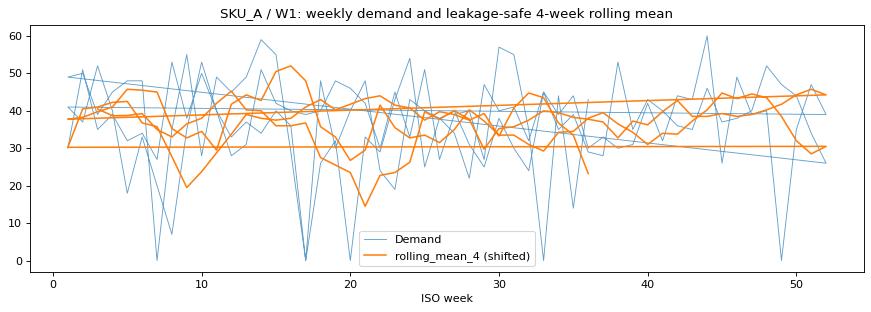

In [7]:
# Visualize: demand vs its leakage-safe rolling mean for one series
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(g['Week'], g['Demand'], label='Demand', lw=0.8, alpha=0.7)
ax.plot(g['Week'], g['feat_rolling_mean_4'], label='rolling_mean_4 (shifted)', lw=1.4)
ax.set_title('SKU_A / W1: weekly demand and leakage-safe 4-week rolling mean')
ax.set_xlabel('ISO week'); ax.legend()
plt.tight_layout(); plt.show()

## 4. SBC demand-pattern classification

From `docs/technical_summary.md`. Two statistics decide which forecasting approach an
item needs:

- **ADI** (Average Demand Interval): mean number of weeks between non-zero sales --
  *how often* does it sell?
- **CV squared**: `(std / mean)^2` of the non-zero quantities -- *how variable* is the
  amount when it does sell?

The cutoffs `ADI = 1.32` and `CV2 = 0.49` split items into four classes, which then
drive how much weight each model (LightGBM / ARIMA / Croston / Two-Stage) gets in the
ensemble.

In [8]:
def sbc_classify(demand):
    d = np.asarray(demand, dtype=float)
    nz = d[d > 0]
    if len(nz) == 0:
        return 'no_demand', np.nan, np.nan
    adi = len(d) / len(nz)                      # avg weeks between sales
    cv2 = (nz.std() / nz.mean()) ** 2 if nz.mean() > 0 else 0.0
    if adi <= 1.32 and cv2 <= 0.49:  cls = 'SMOOTH'
    elif adi <= 1.32 and cv2 > 0.49: cls = 'ERRATIC'
    elif adi > 1.32 and cv2 <= 0.49: cls = 'INTERMITTENT'
    else:                            cls = 'LUMPY'
    return cls, adi, cv2

rows = []
for (s, w), g in df.groupby(['Stock', 'Warehouse']):
    cls, adi, cv2 = sbc_classify(g['Demand'])
    rows.append({'Stock': s, 'Warehouse': w, 'ADI': round(adi, 2),
                 'CV2': round(cv2, 2), 'SBC_class': cls})
pd.DataFrame(rows)

,Stock,Warehouse,ADI,CV2,SBC_class
0,SKU_A,W1,1.04,0.06,SMOOTH
1,SKU_A,W2,2.86,0.59,LUMPY
2,SKU_B,W1,1.22,0.29,SMOOTH


## Takeaways

- **Leakage prevention is structural, not incidental.** Lags use `.shift(lag)`;
  rolling stats use `.shift(1).rolling(window)`. Both are computed per
  Stock/Warehouse group so items never leak into each other.
- **Dynamic selection** keeps short series usable -- a 52-week lag on a 30-week item
  would be all-null, so it's dropped automatically.
- **Classify before you model.** SBC (ADI, CV2) tells you an item's demand shape;
  intermittent/lumpy items need Croston/Two-Stage weight, smooth items lean on
  LightGBM/ARIMA. That's the "which model when" logic the production ensemble uses.
- This is the maturity jump from the school project's flat `create_features`
  (lag_1, lag_7, rolling_7 on one series) to a grouped, config-driven, leakage-tested
  feature layer.

*Re-run locally:* `jupyter lab docs/09-time-series-forecasting/notebooks/distribution-feature-engineering-demo.ipynb`